# Clasificación del riesgo de diabetes mediante aprendizaje automático

## Exploración y calidad de los datos

**Autor:** Alexander Marín  
**Área:** Analítica de datos aplicada al sector salud

### Contexto

Este proyecto analiza el conjunto de datos Pima Indians Diabetes, compuesto por información clínica de 768 mujeres de ascendencia Pima de 21 años o más.

El objetivo general fue desarrollar y comparar modelos de clasificación supervisada para identificar registros con resultado positivo para diabetes.

Antes del modelado se realizó una auditoría de calidad, con énfasis en los valores cero registrados en variables clínicas en las que dicho valor no es biológicamente plausible.



## Fuente y procedencia de los datos

El archivo utilizado correspondía al conjunto **Pima Indians Diabetes Database**,
descargado desde Kaggle:

[Diabetes Dataset — Kaggle](https://www.kaggle.com/datasets/mathchi/diabetes-data-set)

El dataset contiene 768 registros, ocho variables predictoras y una variable
binaria de resultado. Según su documentación histórica, las observaciones
correspondían a mujeres de ascendencia Pima de 21 años o más, pertenecientes a una población ubicada cerca de Phoenix, Arizona, Estados Unidos.

La fuente original se atribuye al National Institute of Diabetes and Digestive
and Kidney Diseases. El conjunto fue utilizado en el trabajo de Smith et al.
(1988) sobre predicción de diabetes mediante el algoritmo ADAP.

Kaggle constituye la fuente de descarga utilizada para este proyecto, pero no la
fuente primaria de recolección de los datos.

Debido a que el dataset representa una población con características
demográficas específicas, los resultados de este ejercicio no pueden
generalizarse automáticamente a hombres, personas menores de 21 años ni otras
poblaciones.


### Pregunta analítica

¿Cómo afecta el tratamiento de los valores faltantes codificados como cero al
desempeño de diferentes modelos de clasificación?

### Alcance

Este proyecto fue un ejercicio educativo de ciencia de datos. Sus resultados no
constituyen una herramienta diagnóstica ni deben utilizarse para tomar decisiones clínicas.

In [2]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42

In [3]:
# cargar datos
DATA_PATH = "/content/1_diabetes.csv"

df = pd.read_csv(DATA_PATH)

print(f"Registros: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")

df.head()

Registros: 768
Variables: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Diccionario de datos

| Variable | Descripción |
|---|---|
| `Pregnancies` | Número de embarazos |
| `Glucose` | Concentración de glucosa plasmática a las dos horas |
| `BloodPressure` | Presión arterial diastólica en mmHg |
| `SkinThickness` | Grosor del pliegue cutáneo del tríceps en mm |
| `Insulin` | Concentración sérica de insulina a las dos horas |
| `BMI` | Índice de masa corporal |
| `DiabetesPedigreeFunction` | Función que representa antecedentes familiares de diabetes |
| `Age` | Edad en años |
| `Outcome` | Resultado registrado: 0 = negativo, 1 = positivo |

In [4]:
# revisar nulos
audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos_explicitos": df.isna().sum(),
    "valores_unicos": df.nunique(),
    "ceros": df.eq(0).sum(),
    "porcentaje_ceros": df.eq(0).mean().mul(100).round(2)
})

print(f"Registros duplicados: {df.duplicated().sum()}")

audit

Registros duplicados: 0


,tipo,nulos_explicitos,valores_unicos,ceros,porcentaje_ceros
Pregnancies,int64,0,17,111,14.45
Glucose,int64,0,136,5,0.65
BloodPressure,int64,0,47,35,4.56
SkinThickness,int64,0,51,227,29.56
Insulin,int64,0,186,374,48.70
BMI,float64,0,248,11,1.43
DiabetesPedigreeFunction,float64,0,517,0,0.00
Age,int64,0,52,0,0.00
Outcome,int64,0,2,500,65.10


### Hallazgos iniciales de calidad

El dataset contiene 768 registros, nueve variables y no presenta registros duplicados ni valores nulos explícitos.

Sin embargo, la ausencia de valores `NaN` no significa que los datos estén completos. Se identificaron valores cero en glucosa, presión arterial, grosor cutáneo, insulina e índice de masa corporal. En estas variables el cero no es biológicamente plausible, por lo que se interpreta como un valor faltante codificado incorrectamente.

El problema es especialmente importante en `Insulin` y `SkinThickness`, con
48,70 % y 29,56 % de ceros, respectivamente.

Si se elimina todas las filas afectadas se reduciría considerablemente el tamaño de la muestra y podría modificar la composición de la población analizada. Por dicho motivo, posteriormente se compararán estrategias de imputación y eliminación.

In [5]:
# ¿Cómo está distribuida la variable objetivo?
outcome_distribution = (
    df["Outcome"]
    .value_counts()
    .sort_index()
    .rename_axis("Outcome")
    .to_frame("frecuencia")
)

outcome_distribution["porcentaje"] = (
    outcome_distribution["frecuencia"] / len(df) * 100
).round(2)

outcome_distribution

,frecuencia,porcentaje
Outcome,,
0,500,65.1
1,268,34.9


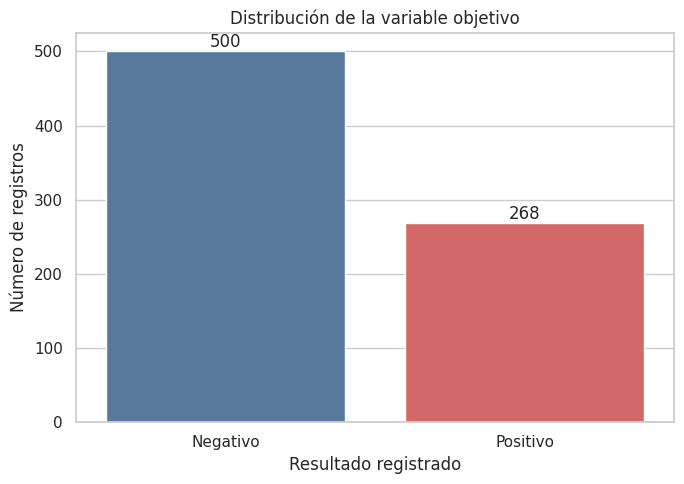

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Outcome",
    hue="Outcome",
    palette=["#4C78A8", "#E45756"],
    legend=False,
    ax=ax
)

ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Resultado registrado")
ax.set_ylabel("Número de registros")
ax.set_xticks([0, 1], ["Negativo", "Positivo"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Distribución de la variable objetivo

El 65,10 % de los registros presenta resultado negativo y el 34,90 % resultado positivo para diabetes.

**Esto indica que existe un desbalance moderado entre las clases. Por esta razón, la exactitud (`accuracy`) no debe utilizarse como única medida de desempeño.**

Ya que podría esperar que un clasificador que asignara todos los registros a la clase negativa alcanzaría una exactitud de 65,10 %, pero no identificaría ningún resultado positivo. Por ello la evaluación posterior incluirá sensibilidad, especificidad, precisión, F1, ROC-AUC y PR-AUC.

In [7]:
# Variables en las que el cero no es clínicamente plausible
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Copia destinada a la exploración
df_eda = df.copy()

# Conversión de ceros clínicamente implausibles en valores faltantes
df_eda[invalid_zero_columns] = (
    df_eda[invalid_zero_columns]
    .replace(0, np.nan)
)

df_eda[invalid_zero_columns].isna().sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


### Tratamiento exploratorio de los ceros

Para realizar la exploración descriptiva, los ceros de las variables clínicas
seleccionadas fueron reemplazados temporalmente por `NaN`.

Esta transformación no constituye todavía una imputación. Su propósito es evitar
que valores clínicamente implausibles distorsionen las estadísticas descriptivas
y las visualizaciones.

El DataFrame original se conserva sin modificaciones.

## Análisis de los valores faltantes encubiertos

In [8]:
# valores faltantes encubiertos
missing_summary = (
    df_eda[invalid_zero_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
    .rename("porcentaje_faltante")
    .to_frame()
)

missing_summary

,porcentaje_faltante
Insulin,48.70
SkinThickness,29.56
BloodPressure,4.56
BMI,1.43
Glucose,0.65


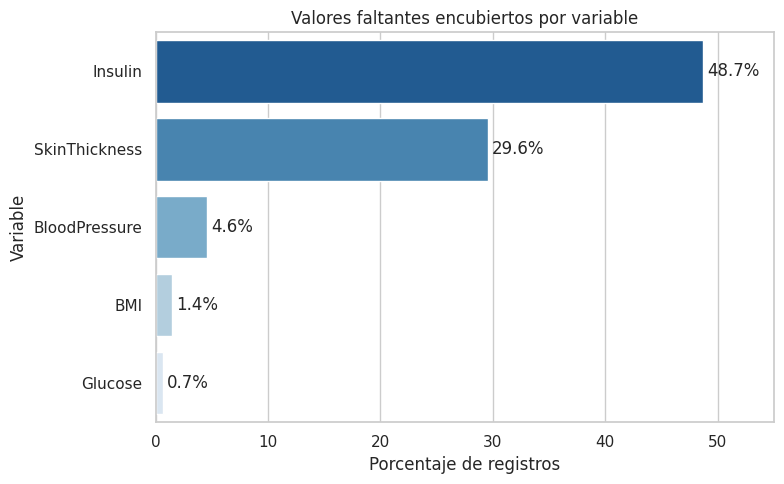

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=missing_summary.reset_index(),
    x="porcentaje_faltante",
    y="index",
    hue="index",
    palette="Blues_r",
    legend=False,
    ax=ax
)

ax.set_title("Valores faltantes encubiertos por variable")
ax.set_xlabel("Porcentaje de registros")
ax.set_ylabel("Variable")
ax.set_xlim(0, 55)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [10]:
# valores faltantes encubiertos por variable
missing_by_outcome = (
    df[invalid_zero_columns]
    .eq(0)
    .groupby(df["Outcome"])
    .mean()
    .mul(100)
    .T
    .round(2)
)

missing_by_outcome.columns = [
    "Outcome negativo",
    "Outcome positivo"
]

missing_by_outcome

,Outcome negativo,Outcome positivo
Glucose,0.6,0.75
BloodPressure,3.8,5.97
SkinThickness,27.8,32.84
Insulin,47.2,51.49
BMI,1.8,0.75


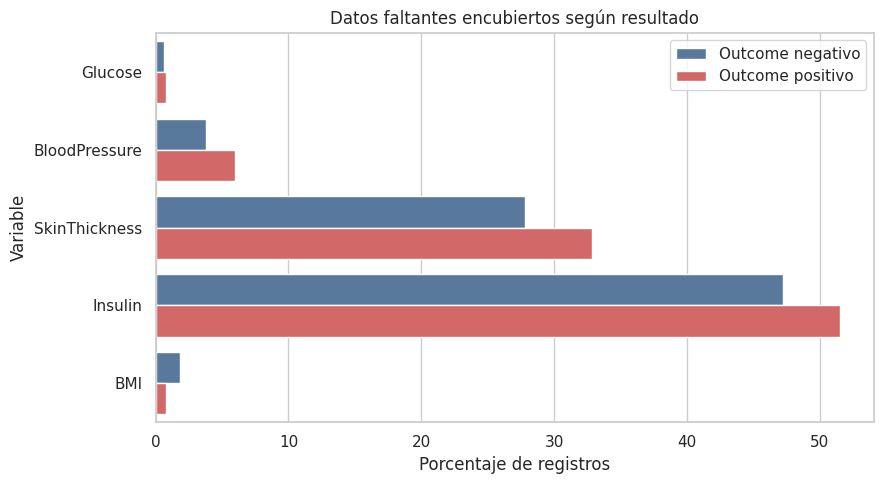

In [11]:
missing_plot = (
    missing_by_outcome
    .reset_index()
    .melt(
        id_vars="index",
        var_name="Resultado",
        value_name="Porcentaje"
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=missing_plot,
    x="Porcentaje",
    y="index",
    hue="Resultado",
    palette=["#4C78A8", "#E45756"],
    ax=ax
)

ax.set_title("Datos faltantes encubiertos según resultado")
ax.set_xlabel("Porcentaje de registros")
ax.set_ylabel("Variable")
ax.legend(title="")

plt.tight_layout()
plt.show()

### Faltantes encubiertos según el resultado

Los registros con resultado positivo presentan una mayor proporción de datos
faltantes en glucosa, presión arterial, grosor cutáneo e insulina.

Las diferencias más visibles se presentan en `SkinThickness`, con 32,84 % de
datos faltantes en los registros positivos frente a 27,80 % en los negativos,
e `Insulin`, con 51,49 % frente a 47,20 %.

En `BMI` se observa el comportamiento contrario: los datos faltantes son más
frecuentes en los registros negativos.

Estas diferencias sugieren que la ausencia de información podría no distribuirse
completamente al azar. Sin embargo, este análisis descriptivo no permite
determinar el mecanismo de ausencia ni establecer causalidad.

Por este motivo, la estrategia utilizada para tratar los datos faltantes puede
afectar tanto el tamaño de la muestra como el desempeño de los modelos.

### Mecanismo de ausencia

Los valores cero permiten identificar mediciones clínicamente implausibles, pero
no explican la razón por la cual dichas mediciones están ausentes. Es por ello que los mecanismos de ausencia suelen clasificarse como MCAR, MAR o MNAR. También pueden existir ausencias estructurales cuando una medición no corresponde según el diseño de la recolección.

Con la información disponible no es posible determinar de manera concluyente el
mecanismo que generó los datos faltantes. Por tanto, se explorarán sus patrones
y asociaciones con variables observadas, evitando clasificarlos automáticamente
como MCAR, MAR o MNAR.

La ausencia simultánea de diferentes mediciones también será evaluada, debido a
que podría reflejar características del proceso de recolección.

Se usará entonces el siguiente código del patrón sigue este orden:

`Glucose – BloodPressure – SkinThickness – Insulin – BMI`

En cada posición:

- `0` indica que la medición está disponible.
- `1` indica que la medición está ausente.

Por ejemplo, `00110` representa registros en los que faltan simultáneamente
`SkinThickness` e `Insulin`.

In [12]:
# patrón de ceros generando ruido en las variables biológicas
missing_indicators = (
    df[invalid_zero_columns]
    .eq(0)
    .astype(int)
    .rename(columns=lambda column: f"{column}_missing")
)

missing_pattern = (
    missing_indicators
    .astype(str)
    .agg("".join, axis=1)
)

pattern_summary = (
    missing_pattern
    .value_counts()
    .rename_axis("patron")
    .reset_index(name="frecuencia")
)

pattern_summary["porcentaje"] = (
    pattern_summary["frecuencia"]
    .div(len(df))
    .mul(100)
    .round(2)
)

pattern_summary

,patron,frecuencia,porcentaje
0,00000,392,51.04
1,00110,192,25.00
2,00010,140,18.23
3,01110,26,3.39
4,01111,7,0.91
5,10010,4,0.52
6,00111,2,0.26
7,01010,2,0.26
8,00011,1,0.13
9,10000,1,0.13


### Interpretación de los patrones de ausencia

El 51,04 % de los registros cuenta con las cinco mediciones clínicas evaluadas,
mientras que el 48,96 % presenta al menos un dato faltante encubierto.

Los principales patrones identificados fueron:

- `00000`: 392 registros sin datos faltantes en las cinco variables.
- `00110`: 192 registros sin mediciones de grosor cutáneo e insulina.
- `00010`: 140 registros sin medición de insulina.

Los demás patrones presentan frecuencias considerablemente menores.

La concentración de la ausencia en `Insulin` y `SkinThickness`, junto con la
aparición simultánea de ambas, sugiere que los datos faltantes podrían estar
relacionados con el proceso de medición o registro.

Este resultado no permite identificar por sí solo un mecanismo MCAR, MAR o MNAR,
pero muestra que los faltantes no aparecen únicamente como eventos aislados.

## Asociación entre la ausencia y las variables observadas

Para explorar si la ausencia de las mediciones está relacionada con información
disponible, se comparan los registros con y sin datos faltantes.

Para las variables numéricas se utiliza la prueba de Mann–Whitney, debido a que
no se presupone normalidad. Para `Outcome` se utiliza la prueba de chi-cuadrado.

Debido a que se realizan múltiples comparaciones, los valores p se ajustan mediante el procedimiento de Benjamini–Hochberg.

In [13]:
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

In [14]:
def benjamini_hochberg(p_values):
    """Ajusta valores p mediante el procedimiento Benjamini-Hochberg."""

    p_values = np.asarray(p_values)
    n_tests = len(p_values)

    order = np.argsort(p_values)
    ranked_p_values = p_values[order]

    adjusted = ranked_p_values * n_tests / np.arange(1, n_tests + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    result = np.empty(n_tests)
    result[order] = adjusted

    return result

In [15]:
fully_observed_variables = [
    "Pregnancies",
    "DiabetesPedigreeFunction",
    "Age"
]

association_results = []

for missing_variable in invalid_zero_columns:

    missing_mask = df[missing_variable].eq(0)

    # Comparaciones con variables numéricas completamente observadas
    for observed_variable in fully_observed_variables:

        available_group = df.loc[
            ~missing_mask,
            observed_variable
        ]

        missing_group = df.loc[
            missing_mask,
            observed_variable
        ]

        statistic, p_value = mannwhitneyu(
            available_group,
            missing_group,
            alternative="two-sided"
        )

        association_results.append({
            "medicion_ausente": missing_variable,
            "variable_observada": observed_variable,
            "resumen_disponible": available_group.median(),
            "resumen_faltante": missing_group.median(),
            "prueba": "Mann-Whitney",
            "valor_p": p_value
        })

    # Comparación del indicador de ausencia con Outcome
    contingency_table = pd.crosstab(
        missing_mask,
        df["Outcome"]
    )

    chi2_statistic, chi2_p_value, _, expected_frequencies = (
        chi2_contingency(
            contingency_table,
            correction=False
        )
    )

    # Utilizar Fisher cuando alguna frecuencia esperada sea menor de 5
    if (expected_frequencies < 5).any():

        statistic, p_value = fisher_exact(
            contingency_table
        )

        test_name = "Fisher exacta"

    else:

        statistic = chi2_statistic
        p_value = chi2_p_value
        test_name = "Chi-cuadrado"

    association_results.append({
        "medicion_ausente": missing_variable,
        "variable_observada": "Outcome",
        "resumen_disponible": df.loc[
            ~missing_mask,
            "Outcome"
        ].mean(),
        "resumen_faltante": df.loc[
            missing_mask,
            "Outcome"
        ].mean(),
        "prueba": test_name,
        "valor_p": p_value
    })


# Convertir los resultados en DataFrame
association_results = pd.DataFrame(
    association_results
)

# Ajustar los valores p por comparaciones múltiples
association_results["valor_p_ajustado"] = (
    benjamini_hochberg(
        association_results["valor_p"]
    )
)

# Identificar asociaciones con valor p ajustado menor de 0,05
association_results["asociacion_detectada"] = np.where(
    association_results["valor_p_ajustado"] < 0.05,
    "Sí",
    "No"
)

# Ordenar los resultados
association_results = (
    association_results
    .sort_values("valor_p_ajustado")
    .reset_index(drop=True)
)

association_results.round(4)

,medicion_ausente,variable_observada,resumen_disponible,resumen_faltante,prueba,valor_p,valor_p_ajustado,asociacion_detectada
0,SkinThickness,Age,28.0000,34.0000,Mann-Whitney,0.0000,0.0000,Sí
1,Insulin,DiabetesPedigreeFunction,0.4495,0.3025,Mann-Whitney,0.0000,0.0000,Sí
2,Insulin,Age,27.0000,32.0000,Mann-Whitney,0.0000,0.0000,Sí
3,SkinThickness,DiabetesPedigreeFunction,0.4170,0.2820,Mann-Whitney,0.0000,0.0000,Sí
4,Insulin,Pregnancies,2.0000,4.0000,Mann-Whitney,0.0000,0.0000,Sí
5,SkinThickness,Pregnancies,2.0000,4.0000,Mann-Whitney,0.0000,0.0000,Sí
6,BMI,Age,29.0000,24.0000,Mann-Whitney,0.0689,0.1970,No
7,BloodPressure,DiabetesPedigreeFunction,0.3800,0.2820,Mann-Whitney,0.0943,0.2357,No
8,SkinThickness,Outcome,0.3327,0.3877,Chi-cuadrado,0.1449,0.3220,No
9,BloodPressure,Outcome,0.3438,0.4571,Chi-cuadrado,0.1693,0.3386,No


### Interpretación de las asociaciones

Después de ajustar los valores p por comparaciones múltiples, se identificaron
seis asociaciones entre la ausencia de mediciones y variables observadas.

Los registros sin medición de insulina presentaron:

- Mayor mediana de edad: 32 frente a 27 años.
- Mayor mediana de embarazos: 4 frente a 2.
- Menor mediana de `DiabetesPedigreeFunction`: 0,30 frente a 0,45.

Los registros sin medición de grosor cutáneo presentaron:

- Mayor mediana de edad: 34 frente a 28 años.
- Mayor mediana de embarazos: 4 frente a 2.
- Menor mediana de `DiabetesPedigreeFunction`: 0,28 frente a 0,42.

No se detectaron asociaciones estadísticamente significativas entre la ausencia
de cada medición y `Outcome` después del ajuste por comparaciones múltiples.

Estos resultados aportan evidencia contra una suposición simple de MCAR, debido
a que la ausencia de insulina y grosor cutáneo está relacionada con
características observadas.

**El comportamiento encontrado es compatible con un posible mecanismo MAR, pero
no permite confirmarlo. Tampoco puede descartarse MNAR, porque no se conocen las
razones de la ausencia ni el proceso original de medición.**

Durante el modelado se compararán estrategias de eliminación, imputación e
incorporación de indicadores de ausencia para evaluar cómo afectan los
resultados.

## Estadísticas descriptivas

In [16]:
descriptive_statistics = (
    df_eda
    .drop(columns="Outcome")
    .describe()
    .T
    .round(2)
)

descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,763.0,121.69,30.54,44.00,99.00,117.00,141.00,199.00
BloodPressure,733.0,72.41,12.38,24.00,64.00,72.00,80.00,122.00
SkinThickness,541.0,29.15,10.48,7.00,22.00,29.00,36.00,99.00
Insulin,394.0,155.55,118.78,14.00,76.25,125.00,190.00,846.00
BMI,757.0,32.46,6.92,18.20,27.50,32.30,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00


In [17]:
median_by_outcome = (
    df_eda
    .groupby("Outcome")
    .median(numeric_only=True)
    .T
    .round(2)
)

median_by_outcome.columns = [
    "Outcome negativo",
    "Outcome positivo"
]

median_by_outcome["diferencia"] = (
    median_by_outcome["Outcome positivo"]
    - median_by_outcome["Outcome negativo"]
).round(2)

median_by_outcome

,Outcome negativo,Outcome positivo,diferencia
Pregnancies,2.00,4.00,2.00
Glucose,107.00,140.00,33.00
BloodPressure,70.00,74.50,4.50
SkinThickness,27.00,32.00,5.00
Insulin,102.50,169.50,67.00
BMI,30.10,34.30,4.20
DiabetesPedigreeFunction,0.34,0.45,0.11
Age,27.00,36.00,9.00


### Comparación descriptiva según el resultado

Los registros con resultado positivo presentan medianas superiores en todas las
variables analizadas.

Las mayores diferencias descriptivas se observan en:

- Glucosa: 140 frente a 107.
- Insulina: 169,5 frente a 102,5.
- Edad: 36 frente a 27 años.
- Número de embarazos: 4 frente a 2.
- IMC: 34,3 frente a 30,1.

Estos resultados permiten identificar patrones potencialmente relevantes para la
clasificación. No obstante, las diferencias entre medianas no demuestran por sí
solas asociación estadística, capacidad predictiva independiente ni causalidad.

Además, las comparaciones de insulina y grosor cutáneo deben interpretarse con
especial cautela debido a su elevada proporción de valores faltantes.

## Distribución de las variables según `Outcome`

Si bien las estadísticas descriptivas muestran diferencias entre los grupos, pero no permiten observar completamente la forma de las distribuciones, su dispersión, asimetría y posibles valores extremos.

A continuación, se comparan gráficamente las ocho variables predictoras entre
los registros con resultado negativo y positivo.

Los valores faltantes permanecen representados como `NaN` y no son imputados
durante esta etapa exploratoria.

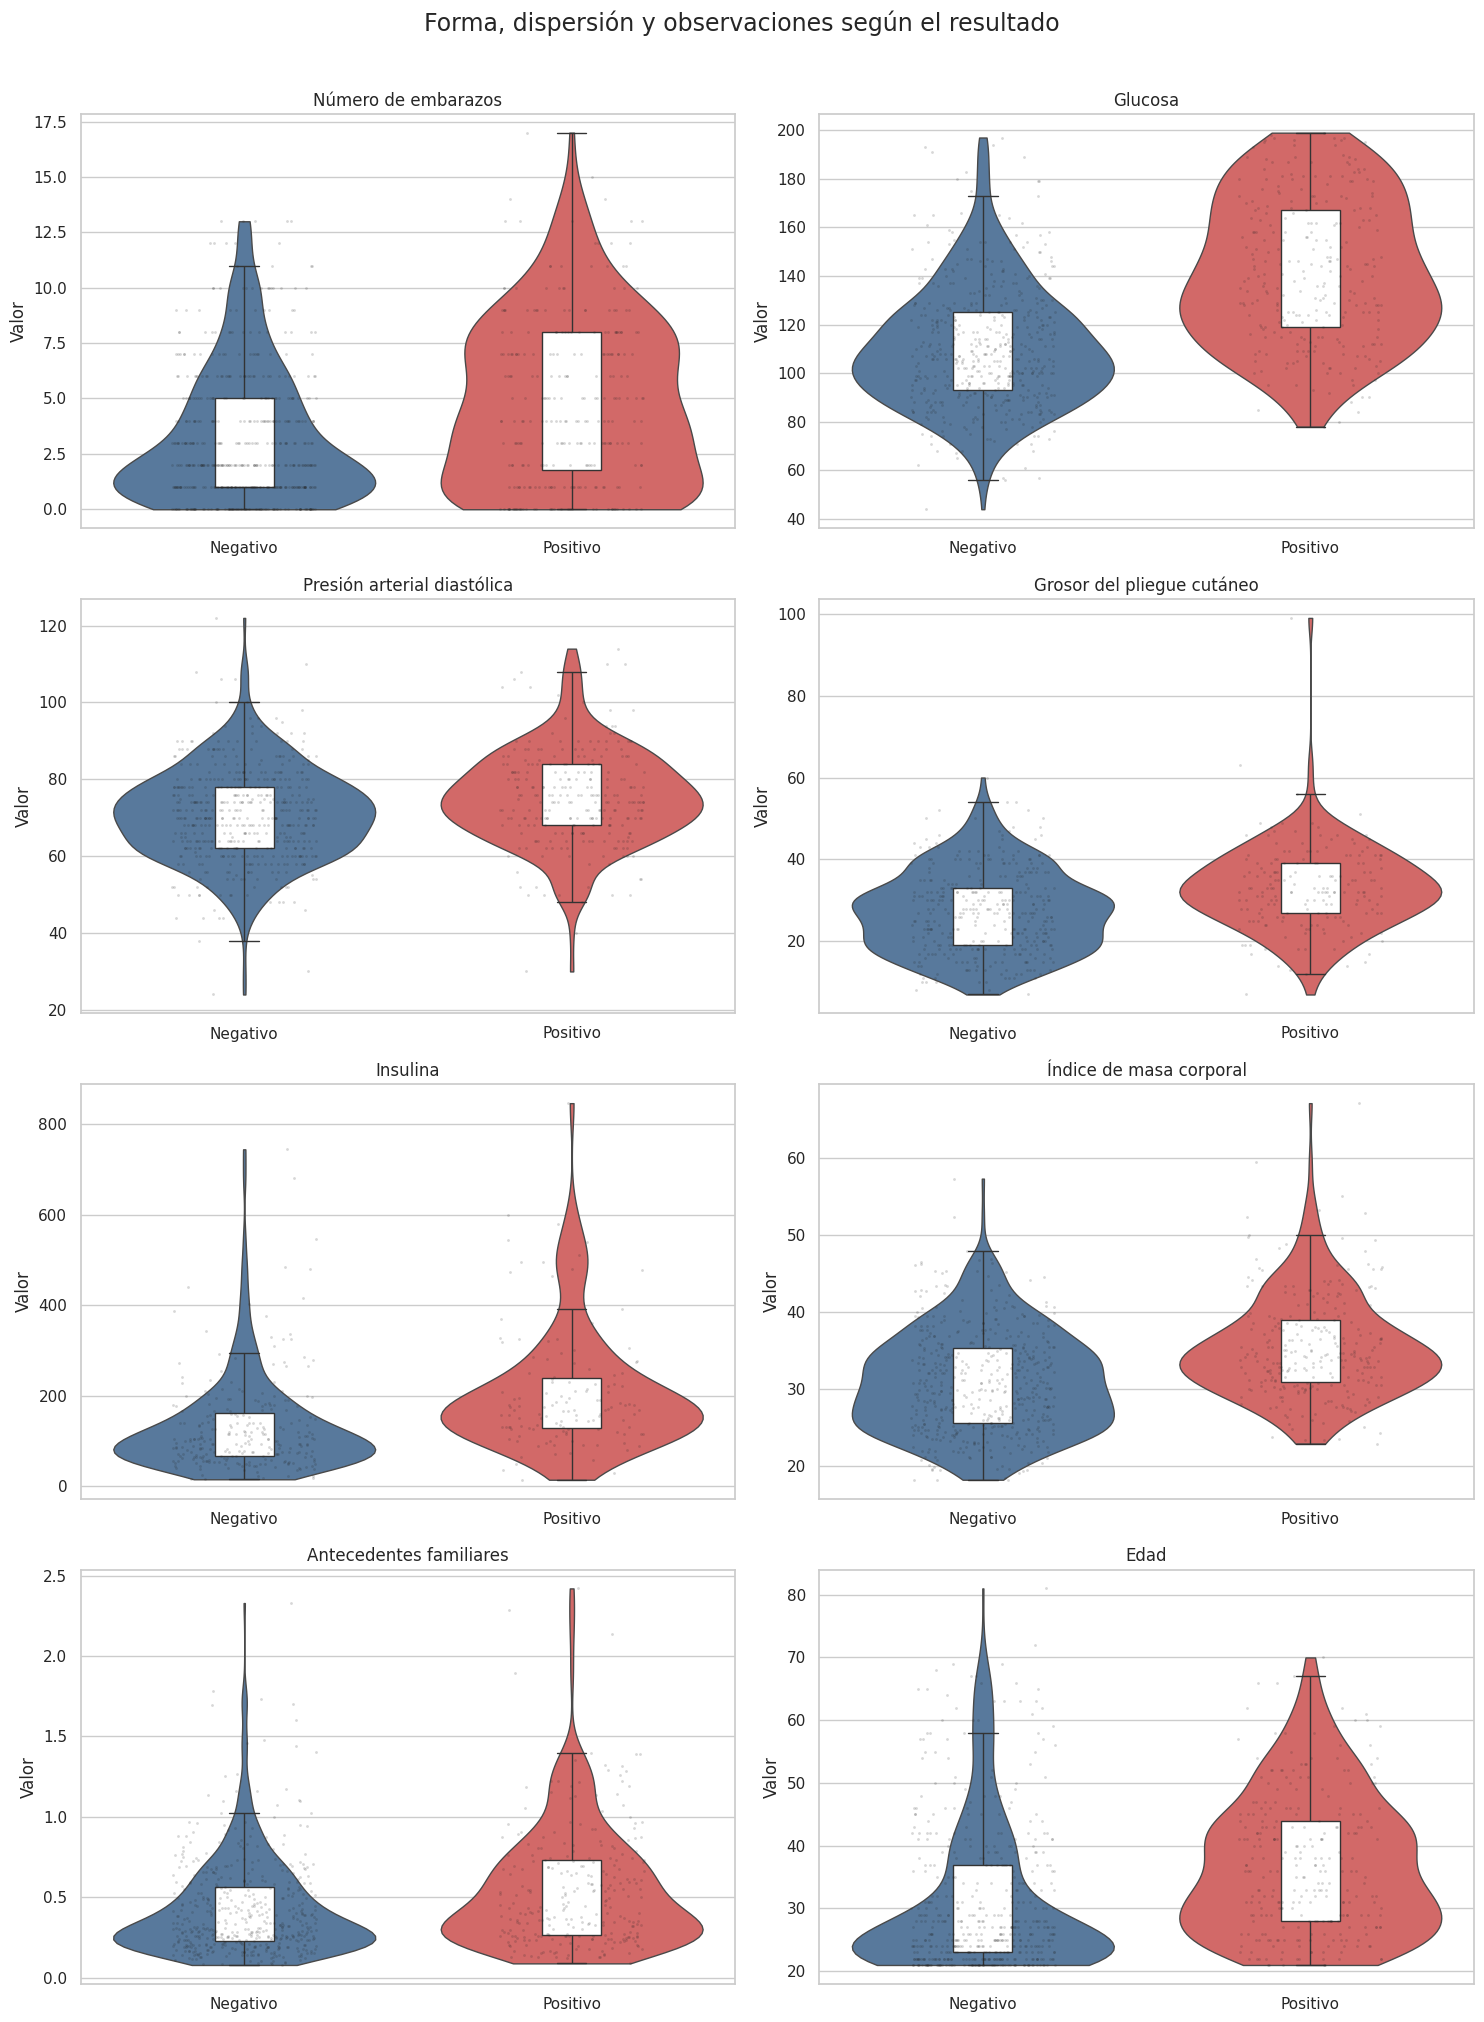

In [18]:
feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

feature_labels = {
    "Pregnancies": "Número de embarazos",
    "Glucose": "Glucosa",
    "BloodPressure": "Presión arterial diastólica",
    "SkinThickness": "Grosor del pliegue cutáneo",
    "Insulin": "Insulina",
    "BMI": "Índice de masa corporal",
    "DiabetesPedigreeFunction": "Antecedentes familiares",
    "Age": "Edad"
}

outcome_labels = {
    0: "Negativo",
    1: "Positivo"
}

color_palette = {
    "Negativo": "#4C78A8",
    "Positivo": "#E45756"
}

df_plot = df_eda.copy()

df_plot["Resultado"] = (
    df_plot["Outcome"]
    .map(outcome_labels)
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(15, 20)
)

axes = axes.flatten()

for ax, variable in zip(axes, feature_columns):

    # Forma y densidad de la distribución
    sns.violinplot(
        data=df_plot,
        x="Resultado",
        y=variable,
        hue="Resultado",
        order=["Negativo", "Positivo"],
        hue_order=["Negativo", "Positivo"],
        palette=color_palette,
        inner=None,
        cut=0,
        density_norm="width",
        common_norm=False,
        linewidth=1,
        saturation=0.75,
        legend=False,
        ax=ax
    )

    # Mediana, cuartiles y rango intercuartílico
    sns.boxplot(
        data=df_plot,
        x="Resultado",
        y=variable,
        hue="Resultado",
        order=["Negativo", "Positivo"],
        hue_order=["Negativo", "Positivo"],
        palette=color_palette,
        width=0.18,
        showfliers=False,
        boxprops={
            "facecolor": "white",
            "edgecolor": "#333333",
            "zorder": 3
        },
        medianprops={
            "color": "#111111",
            "linewidth": 2
        },
        whiskerprops={
            "color": "#333333"
        },
        capprops={
            "color": "#333333"
        },
        legend=False,
        ax=ax
    )

    # Observaciones reales, incluidos los valores extremos
    sns.stripplot(
        data=df_plot,
        x="Resultado",
        y=variable,
        order=["Negativo", "Positivo"],
        color="#222222",
        alpha=0.18,
        jitter=0.22,
        size=2,
        ax=ax
    )

    ax.set_title(
        feature_labels[variable],
        fontsize=12
    )

    ax.set_xlabel("")
    ax.set_ylabel("Valor")

fig.suptitle(
    "Forma, dispersión y observaciones según el resultado",
    fontsize=17,
    y=1.01
)

plt.tight_layout()
plt.show()

### Interpretación de las distribuciones

Las medianas de las ocho variables tienden a ser mayores en los registros con
resultado positivo. Sin embargo, existe superposición entre ambos grupos en
todas las características.

La glucosa presenta la separación visual más clara, con una distribución
desplazada hacia valores mayores en los registros positivos. La edad, el índice
de masa corporal, la insulina y el número de embarazos también muestran
desplazamientos, aunque con superposición considerable.

La presión arterial diastólica presenta distribuciones similares entre los dos
grupos, por lo que su capacidad de discriminación individual parece limitada.

Insulina, antecedentes familiares, edad y embarazos presentan asimetría hacia la
derecha. También se observan valores extremos en diferentes variables,
especialmente insulina, grosor cutáneo, antecedentes familiares e índice de masa
corporal.

Los valores extremos no se eliminan automáticamente, debido a que pueden
representar observaciones clínicas reales. Su influencia será controlada
posteriormente mediante pipelines de preprocesamiento y mediante la comparación
de modelos con diferente sensibilidad a valores extremos.

La superposición observada indica que ninguna característica permite separar por
sí sola los resultados positivos y negativos. Por tanto, el modelado evaluará si
la combinación de múltiples variables mejora la capacidad de clasificación.

## Correlaciones entre variables

Debido a la asimetría, los valores extremos y la presencia de relaciones
potencialmente monotónicas, se utiliza el coeficiente de Spearman.

Spearman calcula la asociación a partir del orden o rango de las observaciones,
por lo que es menos sensible a valores extremos que Pearson y no requiere que la
relación sea estrictamente lineal.

Las correlaciones se calculan utilizando observaciones completas por cada par de
variables. En consecuencia, el número de registros puede variar en las
comparaciones que involucran variables con datos faltantes.

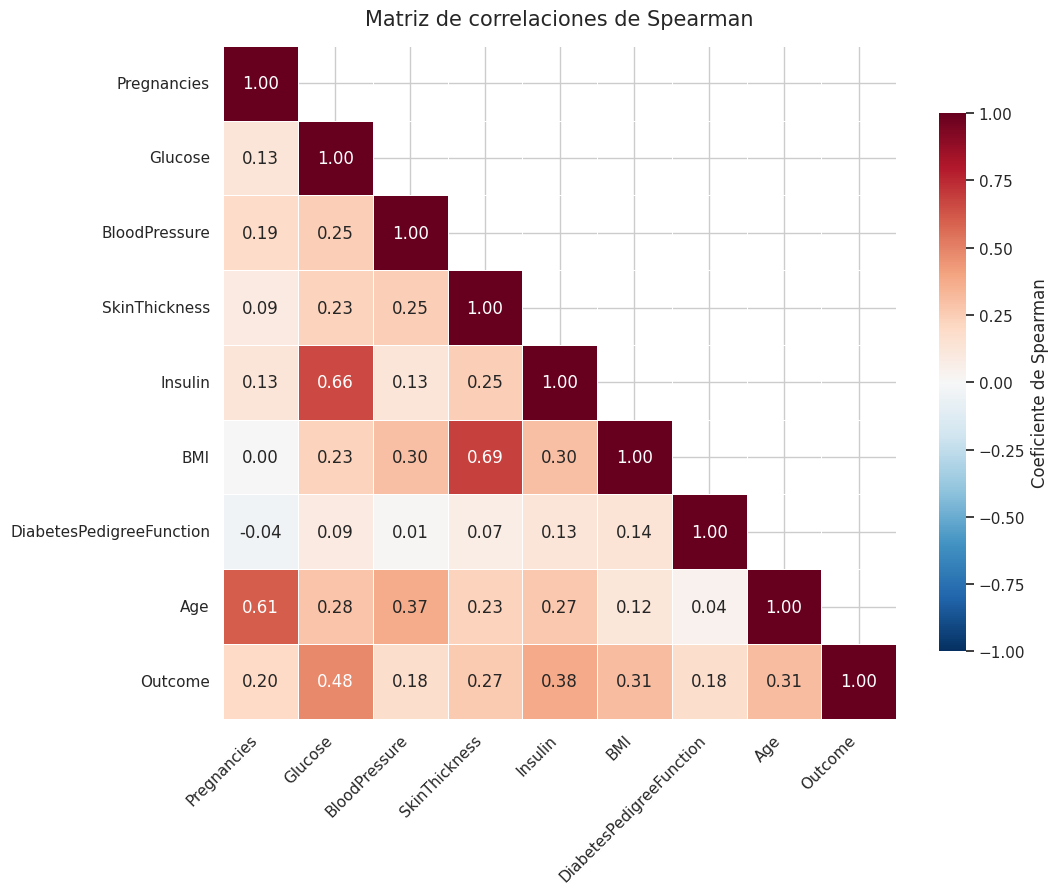

In [19]:
correlation_columns = feature_columns + ["Outcome"]

spearman_correlation = (
    df_eda[correlation_columns]
    .corr(
        method="spearman",
        min_periods=30
    )
)

correlation_mask = np.triu(
    np.ones_like(
        spearman_correlation,
        dtype=bool
    ),
    k=1
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    spearman_correlation,
    mask=correlation_mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "label": "Coeficiente de Spearman",
        "shrink": 0.8
    }
)

plt.title(
    "Matriz de correlaciones de Spearman",
    fontsize=15,
    pad=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [20]:
outcome_correlations = (
    spearman_correlation["Outcome"]
    .drop("Outcome")
    .rename("correlacion_spearman")
    .to_frame()
)

outcome_correlations["n_observaciones"] = (
    df_eda[feature_columns]
    .notna()
    .sum()
)

outcome_correlations = (
    outcome_correlations
    .sort_values(
        "correlacion_spearman",
        ascending=False
    )
    .round(3)
)

outcome_correlations

,correlacion_spearman,n_observaciones
Glucose,0.483,763
Insulin,0.377,394
BMI,0.309,757
Age,0.309,768
SkinThickness,0.265,541
Pregnancies,0.199,768
BloodPressure,0.177,733
DiabetesPedigreeFunction,0.175,768


### Interpretación de las correlaciones

La glucosa presenta la mayor asociación monotónica con `Outcome`, con un
coeficiente de Spearman de 0,483. Este resultado coincide con la separación
observada en las distribuciones de ambos grupos.

La insulina presenta la segunda asociación más alta, con un coeficiente de
0,377. Sin embargo, esta estimación utiliza solamente 394 observaciones debido a
la elevada proporción de datos faltantes, por lo que debe interpretarse con
cautela.

El índice de masa corporal y la edad presentan correlaciones de 0,309 con
`Outcome`. El grosor cutáneo alcanza 0,265, mientras que las asociaciones del
número de embarazos, presión arterial y antecedentes familiares son más débiles.

Entre las variables predictoras se identifican asociaciones moderadas o altas:

- Grosor cutáneo e índice de masa corporal: 0,69.
- Glucosa e insulina: 0,66.
- Número de embarazos y edad: 0,61.
- Presión arterial y edad: 0,37.

Estas relaciones sugieren que algunas características contienen información
parcialmente compartida. No obstante, ninguna correlación entre predictores es
perfecta ni demuestra por sí sola un problema de multicolinealidad.

Las correlaciones se calcularon con observaciones disponibles por cada pareja.
Por esta razón, aquellas que involucran insulina o grosor cutáneo pueden estar
afectadas por el patrón de ausencia y no son directamente comparables con las
calculadas utilizando los 768 registros.

Finalmente, la correlación representa una asociación bivariada. Una correlación
débil no implica que una variable carezca de utilidad predictiva cuando se
combina con otras características.

## Conclusiones del análisis exploratorio

El conjunto de datos contiene 768 registros y no presenta duplicados ni valores
nulos explícitos. Sin embargo, se identificaron ceros clínicamente implausibles
en glucosa, presión arterial, grosor cutáneo, insulina e índice de masa corporal,
los cuales fueron interpretados como datos faltantes encubiertos.

El problema de ausencia afecta especialmente a insulina, con 48,70 %, y grosor
cutáneo, con 29,56 %. Solamente 392 registros, equivalentes al 51,04 % del
dataset, tienen disponibles las cinco mediciones evaluadas.

Los patrones de ausencia y sus asociaciones con edad, número de embarazos y
antecedentes familiares aportan evidencia contra una suposición simple de MCAR.
El comportamiento es compatible con un posible mecanismo MAR, pero no permite
confirmarlo ni descartar MNAR.

Los registros positivos presentan medianas mayores en todas las variables. La
glucosa muestra la separación visual y la correlación individual más clara con
`Outcome`. Edad, índice de masa corporal e insulina también presentan señales
relevantes, aunque existe superposición entre las clases.

Ninguna variable separa completamente los resultados positivos y negativos. Por
tanto, resulta pertinente evaluar modelos que integren simultáneamente las ocho
características.

La eliminación completa de registros con datos faltantes reduciría la muestra y
podría introducir sesgo de selección. En la etapa de modelado se compararán:

1. Eliminación de registros incompletos.
2. Imputación mediante la mediana.
3. Imputación mediante la mediana acompañada de indicadores de ausencia.

El preprocesamiento será aprendido exclusivamente con los datos de entrenamiento
mediante pipelines, evitando que la información del conjunto de prueba influya
en la imputación o el ajuste de los modelos.

## Limitaciones

- El dataset corresponde a una población específica de mujeres de ascendencia
  indígena Pima, por lo que los resultados no pueden generalizarse
  automáticamente a otras poblaciones.
- No se dispone de información sobre el proceso original de medición ni sobre las
  razones de los datos faltantes.
- El mecanismo de ausencia no puede determinarse de manera concluyente.
- Las correlaciones que involucran variables incompletas se calculan con tamaños
  de muestra diferentes.
- Las asociaciones observadas no implican causalidad.
- Este proyecto tiene fines educativos y no constituye una herramienta
  diagnóstica ni una validación clínica.

## Referencias y recursos

1. Kaggle. *Diabetes Dataset*. Disponible en:
   https://www.kaggle.com/datasets/mathchi/diabetes-data-set

2. Smith JW, Everhart JE, Dickson WC, Knowler WC, Johannes RS.
   *Using the ADAP learning algorithm to forecast the onset of diabetes
   mellitus*. Proceedings of the Symposium on Computer Applications and Medical
   Care. 1988:261–265.

3. Pearson RK. *The problem of disguised missing data*. SIGKDD Explorations.
   2006;8(1):83–92. Disponible en:
   https://www.kdd.org/exploration_files/12-Pearson.pdf